Importing

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

loading csv

In [79]:
df = pd.read_csv("data/sudan.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


create column "Country"

In [80]:
df["Country"]="sudan"

changing date

In [81]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Date"].head()

0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]

change month to name

In [82]:

df["Month_Name"] = df["Date"].dt.month_name()

replace -999 with Nan if exist

In [83]:
df = df.replace(-999, np.nan, inplace=True)

check for duplicate row and return how many

In [84]:
df.duplicated().sum()

np.int64(0)


The dataset was checked for duplicate rows using df.duplicated().sum(). The result showed 0 duplicate rows, indicating that all observations are unique. 
Therefore, no rows were removed during the deduplication step.

In [85]:
df = df.drop_duplicates()

describe 

In [86]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN


The dataset contains 4,108 observations from 2015 to 2026 with no missing values, indicating strong data quality. The average temperature (T2M) is 28.76°C, with a wide range from 13.18°C to 37.99°C, showing a hot climate with high variability. Maximum temperatures reach up to 45.96°C, while minimum temperatures drop to 5.93°C, resulting in a large average daily temperature range of 15.27°C, which indicates significant day–night differences. Precipitation (PRECTOTCORR) is generally very low (mean ≈ 0.64 mm, median = 0), but occasional peaks up to 66.49 mm suggest rare but intense rainfall events, leading to a highly skewed distribution. Humidity is relatively low (mean ≈ 31%) with high variability, reflecting dry atmospheric conditions, while wind speeds are moderate. Surface pressure remains stable, showing minimal variation. Overall, the dataset represents a hot, dry climate with large temperature fluctuations and infrequent but sometimes heavy rainfall, making it suitable for further climate variability and extreme event analysis

number of Nan

In [87]:
df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

MIssing value >5%

In [88]:
missing_percent = (df.isna().sum() / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month_Name     0.0
dtype: float64

The percentage of missing values was computed for all columns. The results show that all variables have 0.0% missing values. 
No column exceeds the 5% threshold, indicating that the dataset is complete and suitable for analysis without requiring imputation or removal of variables.

identify outlier using z-score

In [89]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [90]:
z_scores = np.abs(stats.zscore(df[cols]))

In [91]:
outliers_mask=(z_scores>3).any(axis=1)

In [92]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 84


Z-score analysis was performed on key climate variables (T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, WS2M_MAX) using a threshold of |Z| > 3 to detect extreme values. The analysis identified 84 rows as outliers, indicating a moderate presence of unusual observations in the dataset. These outliers are likely driven by extreme temperature variations, occasional heavy rainfall, and wind peaks, which are common in climates with high variability. Since such values can represent real environmental extremes rather than errors, it is recommended to retain them for analysis. However, applying techniques like capping or transformations (e.g., log scaling for precipitation) can help reduce their influence on statistical models while preserving important climate patterns.

Handling missing values

In [93]:
threshold = int(0.3 * len(df.columns))

df = df[df.isna().sum(axis=1) <= threshold]


Forward-fill weather variables

In [94]:
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
df[weather_cols] = df[weather_cols].ffill()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month_Name     0
dtype: int64

cleaned

In [95]:
df_clean = df[~outliers_mask].copy()

In [96]:
print(f"Cleaned rows:{len(df)}")

Cleaned rows:4108


In [97]:
df.to_csv("data/sudan_clean.csv", index=False)

In [98]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

In [99]:
print(df_clean.columns)

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date',
       'Month_Name'],
      dtype='str')


In [100]:
for col in df.columns:
    print(repr(col))


'YEAR'
'DOY'
'T2M'
'T2M_MAX'
'T2M_MIN'
'T2M_RANGE'
'PRECTOTCORR'
'RH2M'
'WS2M'
'WS2M_MAX'
'PS'
'QV2M'
'Country'
'Date'
'Month_Name'


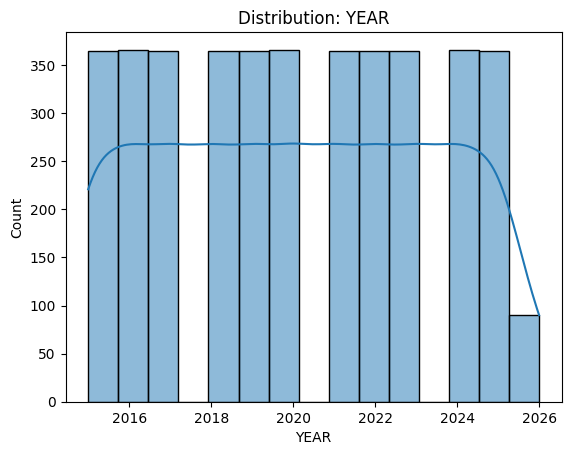

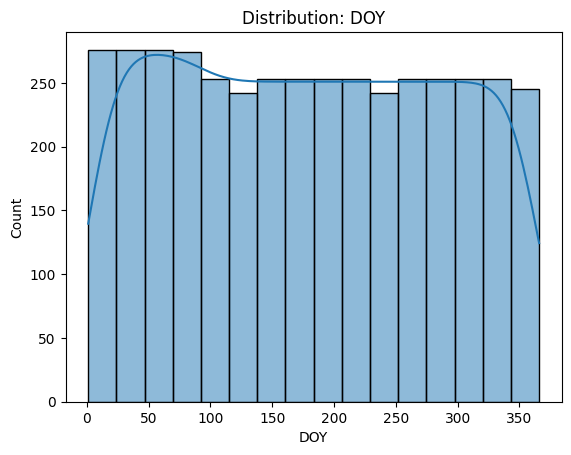

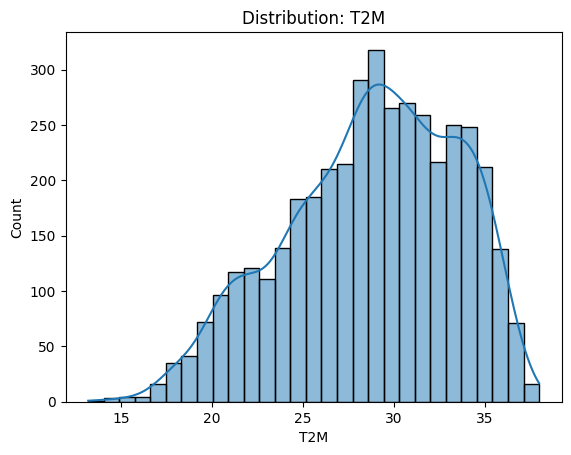

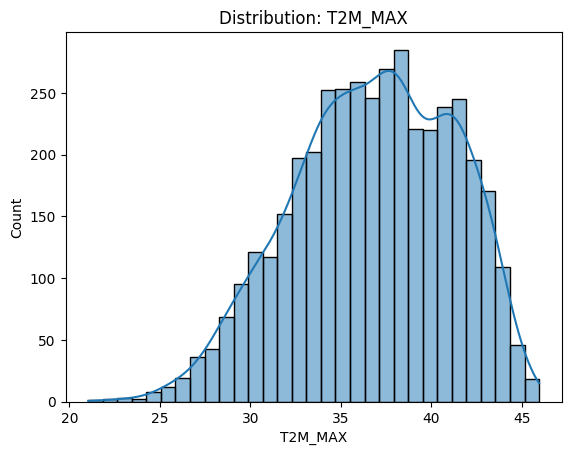

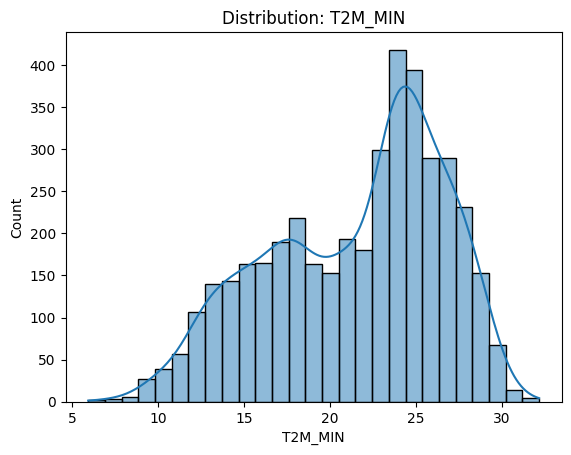

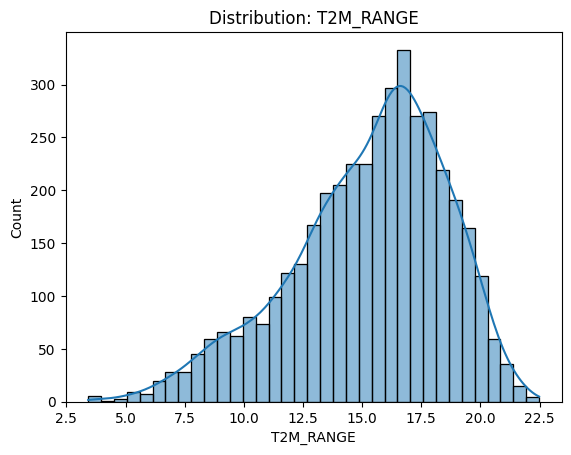

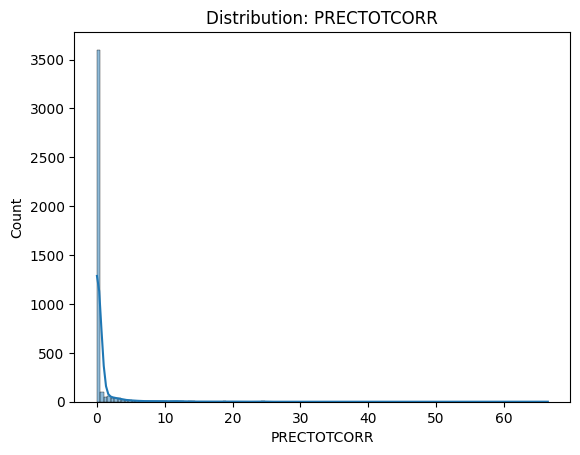

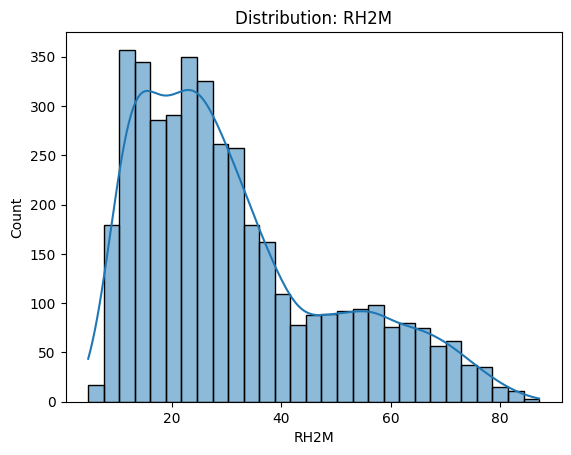

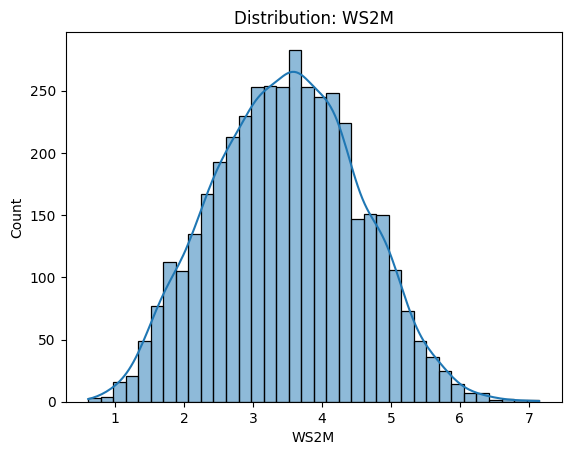

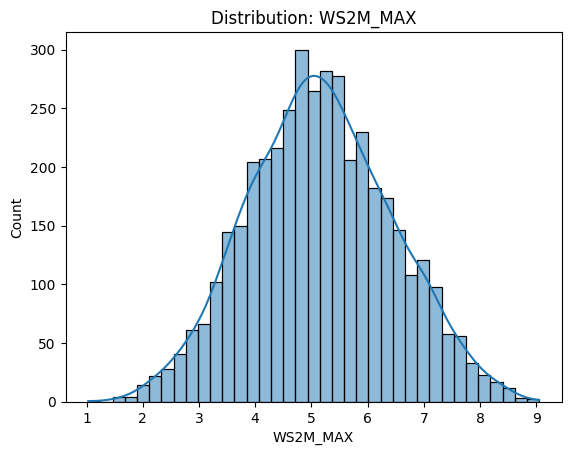

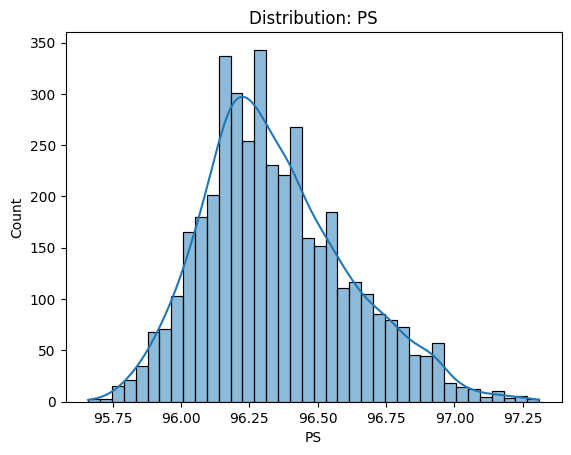

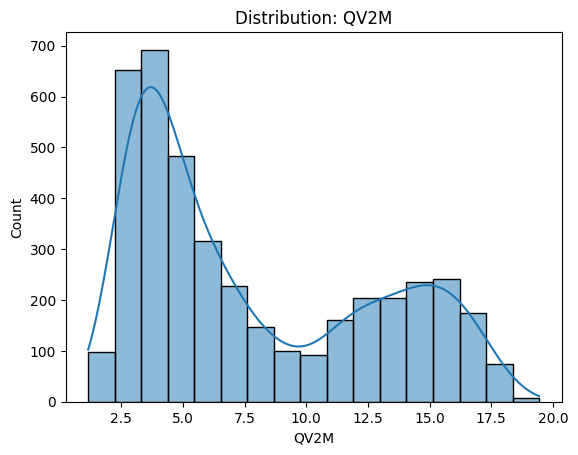

In [101]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    plt.figure()
    sns.histplot(df[c], kde=True)
    plt.title(f"Distribution: {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

In [102]:

df_clean = df[~outliers_mask].copy()

Monthly average T2M

In [103]:

# Set Date as index for resampling
df_clean = df_clean.set_index("Date")

In [104]:

monthly_t2m = df_clean["T2M"].resample("ME").mean()

Find warmest and coolest months

In [105]:

warmest_month = monthly_t2m.idxmax()
coolest_month = monthly_t2m.idxmin()
warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()


plot

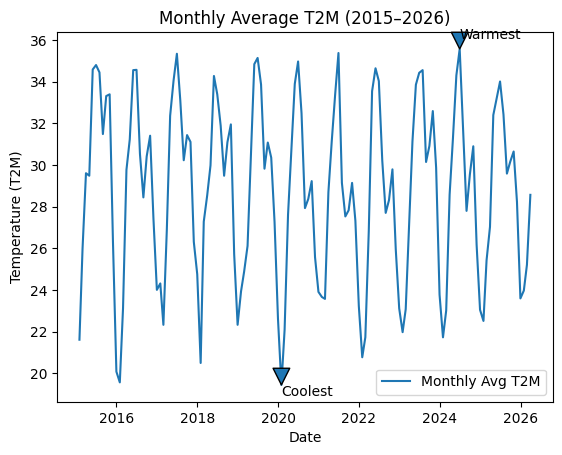

In [106]:
# Plot
plt.plot(monthly_t2m, label="Monthly Avg T2M")
# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_month, warmest_value),
             xytext=(warmest_month, warmest_value + 0.5),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_month, coolest_value),
             xytext=(coolest_month, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

BAR chart for PRECTOTCORR

In [107]:
print(df_clean.head())

            YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  \
Date                                                                            
2015-01-01  2015    1  25.18    35.55    16.14      19.41          0.0  31.87   
2015-01-02  2015    2  23.92    34.14    15.81      18.33          0.0  23.83   
2015-01-03  2015    3  22.73    31.64    15.09      16.55          0.0  38.21   
2015-01-04  2015    4  19.15    27.35    12.88      14.47          0.0  21.07   
2015-01-05  2015    5  17.54    27.22     9.49      17.73          0.0  21.58   

            WS2M  WS2M_MAX     PS  QV2M Country Month_Name  
Date                                                        
2015-01-01  3.46      5.12  96.54  6.08   sudan    January  
2015-01-02  4.24      5.10  96.67  4.31   sudan    January  
2015-01-03  5.01      6.24  96.77  6.42   sudan    January  
2015-01-04  5.72      6.96  96.93  3.06   sudan    January  
2015-01-05  4.28      5.82  96.85  2.86   sudan    January  


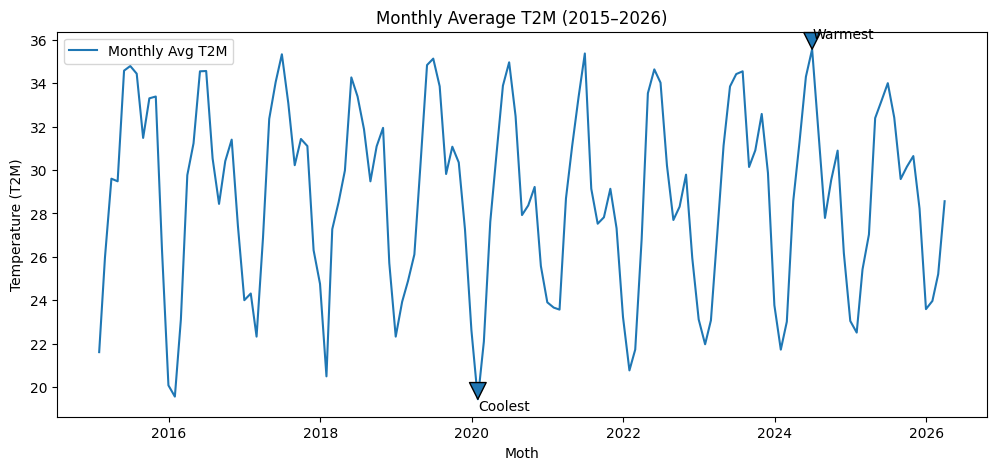

In [108]:


# Find warmest and coolest months
warmest_date = monthly_t2m.idxmax()
coolest_date = monthly_t2m.idxmin()

warmest_value = monthly_t2m.max()
coolest_value = monthly_t2m.min()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_t2m, label="Monthly Avg T2M")

# Annotate warmest month
plt.annotate("Warmest",
             xy=(warmest_date, warmest_value),
             xytext=(warmest_date, warmest_value + 0.5),
             arrowprops=dict())

# Annotate coolest month
plt.annotate("Coolest",
             xy=(coolest_date, coolest_value),
             xytext=(coolest_date, coolest_value - 0.5),
             arrowprops=dict())

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Moth")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()


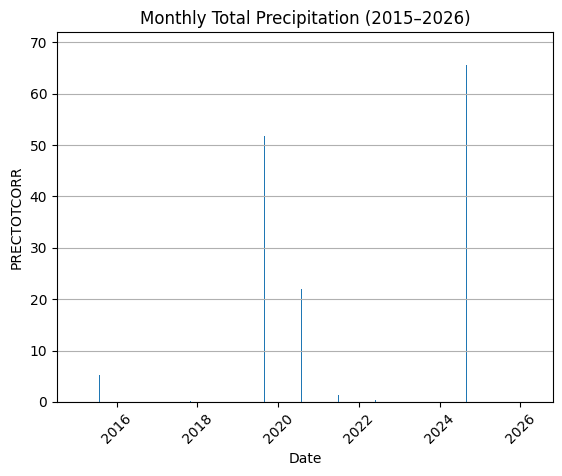

In [109]:
# Monthly average T2M
monthly_precip = df_clean["PRECTOTCORR"].resample("ME").sum()
plt.bar(monthly_precip.index, monthly_precip.values)
plt.title("Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("PRECTOTCORR")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

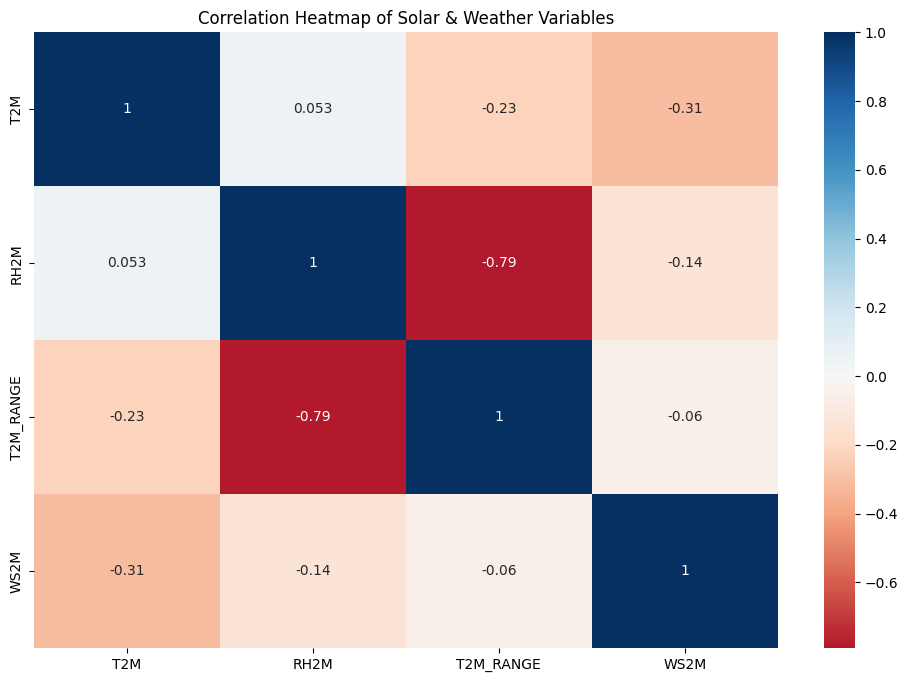

In [110]:

#selecting main columns for correlation
corr_cols = ['T2M', 'RH2M', 'T2M_RANGE', 'WS2M']
correlation_matrix = df_clean[corr_cols].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', center=0)
plt.title('Correlation Heatmap of Solar & Weather Variables')
plt.show()

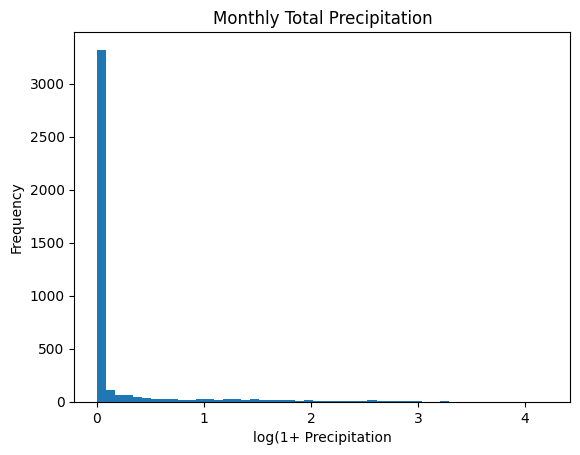

In [111]:


plt.hist(np.log1p(df["PRECTOTCORR"].dropna()), bins=50)
plt.title("Monthly Total Precipitation")
plt.xlabel("log(1+ Precipitation")
plt.ylabel("Frequency")
plt.show()

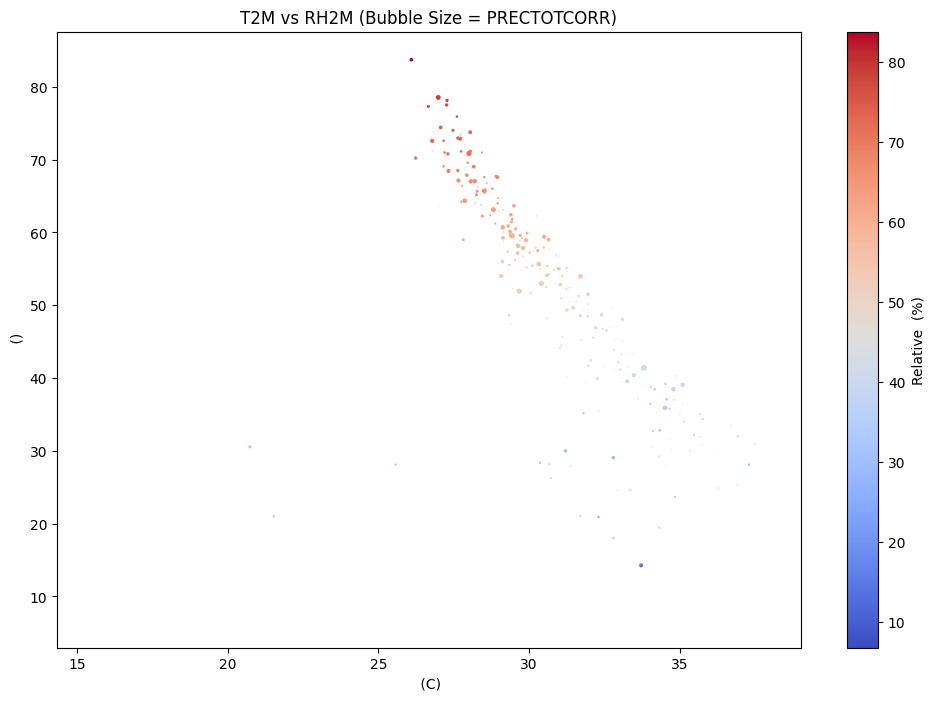

In [112]:
# Select a small random sample (e.g., 1000 rows) so the bubbles aren't too crowded
sample_bubble = df_clean.sample(1000)

plt.figure(figsize=(12, 8))
plt.scatter(sample_bubble['T2M'], sample_bubble['RH2M'], 
            s=sample_bubble['PRECTOTCORR'], # Size of bubble
            c=sample_bubble['RH2M'], # Color can also 
            cmap='coolwarm')

plt.title('T2M vs RH2M (Bubble Size = PRECTOTCORR)')
plt.xlabel(' (C)')
plt.ylabel(' ()')
plt.colorbar(label='Relative  (%)')
plt.show()
